# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">DS540-PROJECT
</p>

In [1]:
# import libraries
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import optuna
%matplotlib inline 
sns.set_style('whitegrid')
pd.options.display.float_format = '{:.2f}'.format

/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# read csv
df = pd.read_csv('crsp_with_technical_features.csv')

In [3]:
# filter top 5 companies
target_tickers = ['BA', 'GM', 'C', 'BAC', 'T']
df = df[df['ticker'].isin(target_tickers)]

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:60%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">EDA
</p>

In [4]:
df.comnam.unique().tolist()

['BOEING CO',
 'BANK OF AMERICA CORP',
 'CITIGROUP INC',
 'GENERAL MOTORS CO',
 'A T & T INC']

In [5]:
len(df.comnam.unique())

5

In [6]:
df.columns

Index(['permno', 'date', 'shrcd', 'exchcd', 'ticker', 'comnam', 'trdstat',
       'secstat', 'permco', 'cusip', 'bidlo', 'askhi', 'prc', 'vol', 'ret',
       'shrout', 'cfacpr', 'cfacshr', 'openprc', 'retx', 'vwretd', 'ewretd',
       'market_cap', 'momentum_5d', 'ma_20d', 'volatility_30d', 'rsi_14',
       'macd', 'macd_signal', 'bb_upper', 'bb_lower', 'target_ret',
       'target_class'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6120 entries, 156665 to 1362432
Data columns (total 33 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   permno          6120 non-null   int64  
 1   date            6120 non-null   object 
 2   shrcd           6120 non-null   float64
 3   exchcd          6120 non-null   float64
 4   ticker          6120 non-null   object 
 5   comnam          6120 non-null   object 
 6   trdstat         6120 non-null   object 
 7   secstat         6120 non-null   object 
 8   permco          6120 non-null   int64  
 9   cusip           6120 non-null   object 
 10  bidlo           6120 non-null   float64
 11  askhi           6120 non-null   float64
 12  prc             6120 non-null   float64
 13  vol             6120 non-null   float64
 14  ret             6120 non-null   float64
 15  shrout          6120 non-null   float64
 16  cfacpr          6120 non-null   float64
 17  cfacshr         6120 non-

In [8]:
# Check for missing values, sorted by count
df.isnull().sum().sort_values(ascending=False)

permno            0
cfacshr           0
target_ret        0
bb_lower          0
bb_upper          0
macd_signal       0
macd              0
rsi_14            0
volatility_30d    0
ma_20d            0
momentum_5d       0
market_cap        0
ewretd            0
vwretd            0
retx              0
openprc           0
cfacpr            0
date              0
shrout            0
ret               0
vol               0
prc               0
askhi             0
bidlo             0
cusip             0
permco            0
secstat           0
trdstat           0
comnam            0
ticker            0
exchcd            0
shrcd             0
target_class      0
dtype: int64

Class 0: 3056
Class 1: 3064
Proportion: 0.997


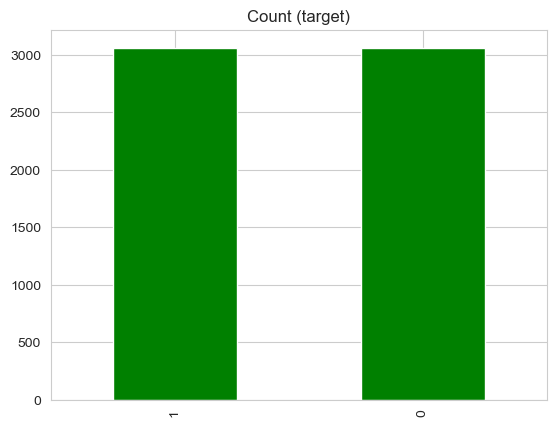

In [9]:
target_count = df['target_class'].value_counts()
print('Class 0:', target_count[0])
print('Class 1:', target_count[1])
print('Proportion:', round(target_count[0] / target_count[1], 3))

target_count.plot(kind='bar', title='Count (target)' ,  color='green');

In [10]:
# Convert the 'date' column to datetime format (day/month/year)
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y', errors='coerce')

# Count the number of observations per firm (by ticker)
firm_distribution = df['ticker'].value_counts().reset_index()

# Determine the date range in the dataset
date_range = (df['date'].min(), df['date'].max())

In [11]:
date_range

(Timestamp('2020-01-02 00:00:00'), Timestamp('2024-12-30 00:00:00'))

In [12]:
firm_distribution

,index,ticker
0,BA,1224
1,BAC,1224
2,C,1224
3,GM,1224
4,T,1224


In [14]:
df_recent = df[df['date'] >= '2023-01-01'].copy()

# Sort again just in case
df_recent = df_recent.sort_values(by='date').reset_index(drop=True)

# Perform a time-based 80/20 train-test split
split_index = int(len(df_recent) * 0.8)
train_df = df_recent.iloc[:split_index]
test_df = df_recent.iloc[split_index:]

# Show the number of samples in the new train/test sets
train_count = len(train_df)
test_count = len(test_df)

train_count, test_count

(1952, 488)

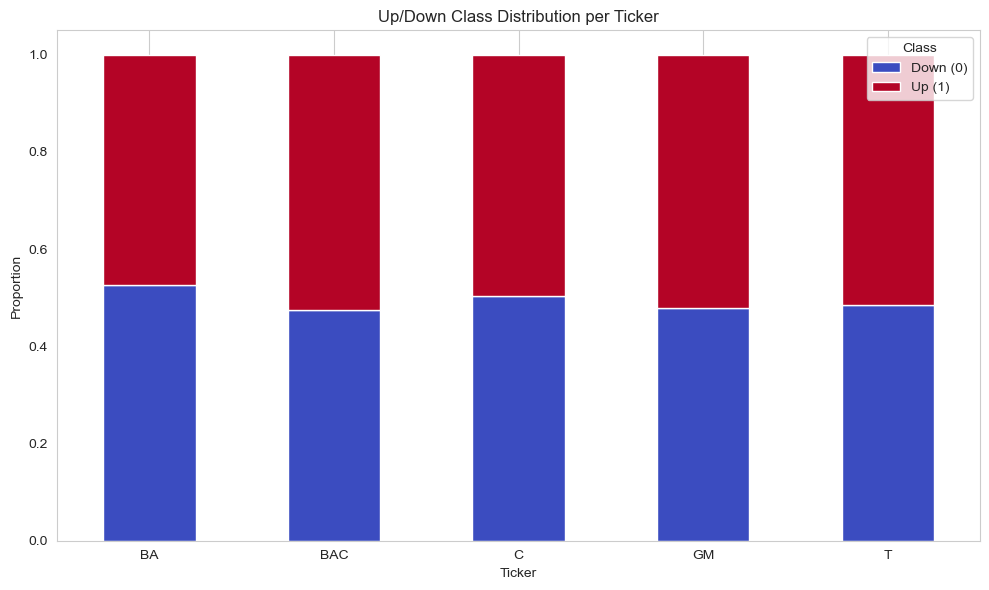

In [15]:
# Calculate up/down distribution per ticker
class_distribution = train_df.groupby('ticker')['target_class'].value_counts(normalize=True).unstack().fillna(0)

# Plot the results
ax = class_distribution.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm')
plt.title('Up/Down Class Distribution per Ticker')
plt.xlabel('Ticker')
plt.ylabel('Proportion')
plt.legend(['Down (0)', 'Up (1)'], title='Class')
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

In [16]:
# Calculate exact ratios of 'up' (1) and 'down' (0) per ticker
distribution_ratios = train_df.groupby('ticker')['target_class'].value_counts(normalize=True).unstack().fillna(0)
distribution_ratios.columns = ['Down (0)', 'Up (1)']
distribution_ratios_sorted = distribution_ratios.sort_values(by='Up (1)', ascending=False)

distribution_ratios_sorted

,Down (0),Up (1)
ticker,,
BAC,0.47,0.53
GM,0.48,0.52
T,0.49,0.51
C,0.50,0.50
BA,0.53,0.47


###### BAC and GM show a modest bullish behavior – could influence models to slightly favor upward predictions.
###### C (Citigroup) stands out as the most neutral ticker in terms of class balance.
###### BA (Boeing) has the highest proportion of downward days, which may indicate weaker short-term momentum compared to peers.

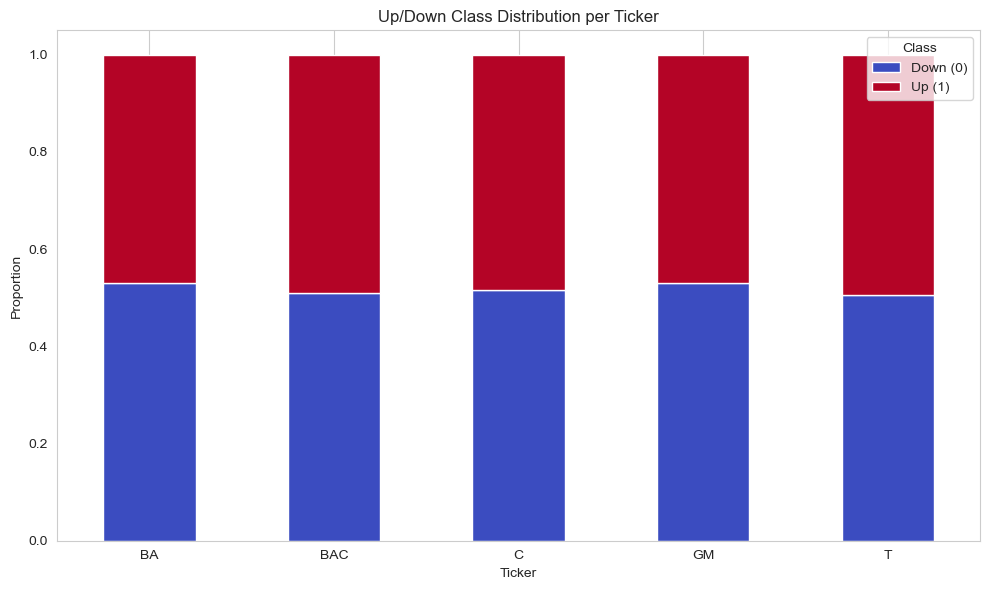

In [17]:
# Calculate up/down distribution per ticker
class_distribution = test_df.groupby('ticker')['target_class'].value_counts(normalize=True).unstack().fillna(0)

# Plot the results
ax = class_distribution.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm')
plt.title('Up/Down Class Distribution per Ticker')
plt.xlabel('Ticker')
plt.ylabel('Proportion')
plt.legend(['Down (0)', 'Up (1)'], title='Class')
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

In [18]:
# Calculate exact ratios of 'up' (1) and 'down' (0) per ticker for test set
distribution_ratios = test_df.groupby('ticker')['target_class'].value_counts(normalize=True).unstack().fillna(0)
distribution_ratios.columns = ['Down (0)', 'Up (1)']
distribution_ratios_sorted_test = distribution_ratios.sort_values(by='Up (1)', ascending=False)

distribution_ratios_sorted_test

,Down (0),Up (1)
ticker,,
T,0.51,0.49
BAC,0.51,0.49
C,0.52,0.48
BA,0.53,0.47
GM,0.53,0.47


###### There is a systematic shift toward more “Down” days in the test set across all tickers.
###### GM and BAC show the largest drop in “Up” class proportion – from ~52% to 47–49%.
###### This kind of shift could negatively impact a model trained on slightly bullish data, especially if the model learned a strong upward trend bias.

##### That is why we will use class-weighted loss functions or evaluation metrics like ROC AUC, F1-score to adjust for this shift.

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:60%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">PREPROCESSING
</p>

In [19]:
# Apply Label Encoding to the 'ticker' column again (in case it was lost or overwritten)
label_encoder = LabelEncoder()
train_df['ticker_code'] = label_encoder.fit_transform(train_df['ticker'])
test_df['ticker_code'] = label_encoder.transform(test_df['ticker'])
# Show the mapping for clarity
ticker_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
ticker_mapping

/var/folders/nj/gq42w_fj4r3cnfhd1zbgq19w0000gn/T/ipykernel_13557/2605525424.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['ticker_code'] = label_encoder.fit_transform(train_df['ticker'])
/var/folders/nj/gq42w_fj4r3cnfhd1zbgq19w0000gn/T/ipykernel_13557/2605525424.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['ticker_code'] = label_encoder.transform(test_df['ticker'])


{'BA': 0, 'BAC': 1, 'C': 2, 'GM': 3, 'T': 4}

In [20]:
df_recent['ticker_code'] = label_encoder.fit_transform(df_recent['ticker'])

In [21]:
# Drop unnecessary columns
cols_to_drop = ['target_ret', 'date', 'ticker', 'comnam', 'cusip', 'permco','trdstat', 'secstat']
X_train = train_df.drop(columns=cols_to_drop + ['target_class'])
y_train = train_df['target_class']
X_test = test_df.drop(columns=cols_to_drop + ['target_class'])
y_test = test_df['target_class']

In [22]:
X_train.corr()

,permno,shrcd,exchcd,bidlo,askhi,prc,vol,ret,shrout,cfacpr,...,market_cap,momentum_5d,ma_20d,volatility_30d,rsi_14,macd,macd_signal,bb_upper,bb_lower,ticker_code
permno,1.00,NaN,NaN,-0.53,-0.53,-0.53,0.47,0.01,0.64,NaN,...,0.42,-0.23,-0.53,-0.46,-0.38,-0.08,-0.07,-0.54,-0.49,0.27
shrcd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
exchcd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bidlo,-0.53,NaN,NaN,1.00,1.00,1.00,-0.52,-0.01,-0.60,NaN,...,-0.06,0.19,0.98,0.45,0.55,0.20,0.15,0.98,0.98,-0.75
askhi,-0.53,NaN,NaN,1.00,1.00,1.00,-0.51,-0.01,-0.60,NaN,...,-0.06,0.19,0.99,0.45,0.55,0.20,0.15,0.98,0.98,-0.75
prc,-0.53,NaN,NaN,1.00,1.00,1.00,-0.51,-0.01,-0.60,NaN,...,-0.06,0.19,0.99,0.45,0.55,0.20,0.15,0.98,0.98,-0.75
vol,0.47,NaN,NaN,-0.52,-0.51,-0.51,1.00,-0.01,0.74,NaN,...,0.48,-0.15,-0.52,-0.31,-0.35,-0.05,-0.05,-0.52,-0.51,0.24
ret,0.01,NaN,NaN,-0.01,-0.01,-0.01,-0.01,1.00,0.00,NaN,...,0.02,0.05,-0.02,-0.02,0.07,-0.02,-0.04,-0.02,-0.02,0.01
shrout,0.64,NaN,NaN,-0.60,-0.60,-0.60,0.74,0.00,1.00,NaN,...,0.70,-0.18,-0.61,-0.49,-0.34,-0.06,-0.08,-0.61,-0.60,0.29
cfacpr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<AxesSubplot:>

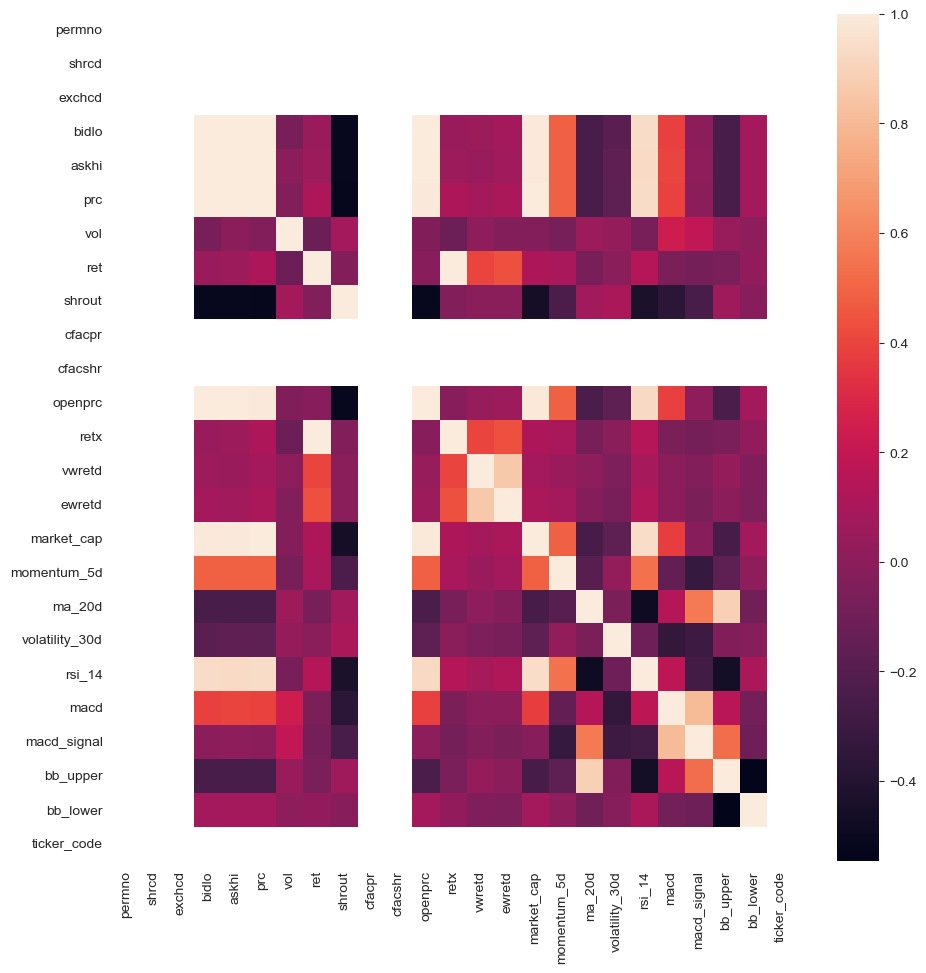

In [97]:
correlation_matrix = X_train.corr()
fig, ax = plt.subplots()
fig.set_size_inches(11,11)
sns.heatmap(correlation_matrix)

In [23]:
# Correlation filter - remove features with correlation > 0.7
correlation_matrix_abs = X_train.corr().abs()
upper_triangle = correlation_matrix_abs.where(
    pd.np.triu(pd.np.ones(correlation_matrix_abs.shape), k=1).astype(bool)
)
high_corr_features = [
    column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)
]

/var/folders/nj/gq42w_fj4r3cnfhd1zbgq19w0000gn/T/ipykernel_13557/1021835554.py:4: FutureWarning: The pandas.np module is deprecated and will be removed from pandas in a future version. Import numpy directly instead.
  pd.np.triu(pd.np.ones(correlation_matrix_abs.shape), k=1).astype(bool)


In [24]:
high_corr_features

['askhi', 'prc', 'openprc', 'retx', 'ma_20d', 'bb_upper', 'bb_lower']

In [25]:
X_corr_filtered = X_train.drop(columns=high_corr_features)

In [26]:
# Variance filter - remove features with near-zero variance
vt = VarianceThreshold(threshold=0.01)
X_var_filtered = pd.DataFrame(
    vt.fit_transform(X_corr_filtered),
    columns=X_corr_filtered.columns[vt.get_support()]
)

In [27]:
# Recursive Feature Elimination (RFE) with Random Forest
rf_estimator = RandomForestClassifier(n_estimators=100, random_state=1995)
rfe_selector = RFE(rf_estimator, n_features_to_select=10)
rfe_selector.fit(X_var_filtered, y_train)

# Get selected features
selected_features = X_var_filtered.columns[rfe_selector.support_]

In [28]:
selected_features

Index(['permno', 'bidlo', 'vol', 'shrout', 'market_cap', 'momentum_5d',
       'rsi_14', 'macd', 'macd_signal', 'ticker_code'],
      dtype='object')

In [29]:
# Final feature set
X_final = X_var_filtered[selected_features]

In [30]:
X_final.drop('permno', axis=1, inplace=True)

In [50]:
X_final = X_final[selected_features]

In [31]:
X_final

,bidlo,vol,shrout,market_cap,momentum_5d,rsi_14,macd,macd_signal,ticker_code
0,192.40,8624570.00,595983.00,116449.12,-0.03,49.83,6.69,1.88,0.00
1,18.41,42149170.00,7127000.00,133559.98,-0.19,47.68,0.48,0.28,4.00
2,33.21,35221501.00,8022432.00,268831.70,-0.25,49.14,1.40,0.87,1.00
3,45.53,19563965.00,1936853.00,88669.13,-0.28,47.05,1.07,0.45,2.00
4,33.40,11793319.00,1420697.00,48047.97,-0.45,47.80,1.29,1.03,3.00
...,...,...,...,...,...,...,...,...,...
1947,19.21,25588147.00,7170244.00,139102.73,-0.31,48.34,-1.20,-0.37,4.00
1948,37.66,36557830.00,7759577.00,296493.44,-0.01,51.95,0.07,-0.30,1.00
1949,41.09,17717876.00,1123922.00,48025.19,-0.24,50.60,-0.37,-0.49,3.00
1950,57.45,11421029.00,1907440.00,110326.33,-0.16,50.08,-0.16,0.44,2.00


# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:60%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">MODEL
</p>

In [32]:
# XGBoost
xgb_model = XGBClassifier( n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=1995)
xgb_model.fit(X_final, y_train)

/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=1995, ...)

In [33]:
y_proba_train = xgb_model.predict_proba(X_final)[:, 1]

In [34]:
print("ROC AUC:", roc_auc_score(y_train, y_proba_train))

ROC AUC: 0.7788340794933392


In [35]:
X_final.columns.tolist()

['bidlo',
 'vol',
 'shrout',
 'market_cap',
 'momentum_5d',
 'rsi_14',
 'macd',
 'macd_signal',
 'ticker_code']

In [36]:
# Predictions and Evaluation
y_pred = xgb_model.predict(X_test[X_final.columns.tolist()])
y_proba = xgb_model.predict_proba(X_test[X_final.columns.tolist()])[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.55      0.72      0.62       253
           1       0.54      0.36      0.43       235

    accuracy                           0.54       488
   macro avg       0.54      0.54      0.52       488
weighted avg       0.54      0.54      0.53       488

ROC AUC: 0.5260701370784627


In [37]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1.0),
        'use_label_encoder': False,
        'eval_metric': 'logloss'
    }

    model = XGBClassifier(**params)
    model.fit(X_final, y_train)
    y_pred = model.predict_proba(X_test[X_final.columns.tolist()])[:, 1]
    return roc_auc_score(y_test, y_pred)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print("Best parameters:", study.best_params)
print("Best AUC:", study.best_value)

[I 2025-05-23 21:41:11,796] A new study created in memory with name: no-name-bbc42a9d-0f5e-490f-9dba-a54b00d0e349
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:12,026] Trial 0 finished with value: 0.5046337566226557 and parameters: {'n_estimators': 237, 'max_depth': 5, 'learning_rate': 0.20667544952207934, 'subsample': 0.7791073366516403, 'colsample_bytree': 0.5974796682348265, 'reg_alpha': 0.6095735530729597, 'reg_lambda': 0.6822798348741158}. Best is trial 0 with value: 0.5046337566226557.
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:12,773] Trial 1 finished with value: 0.511479

/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:20,027] Trial 14 finished with value: 0.5294928937852157 and parameters: {'n_estimators': 226, 'max_depth': 5, 'learning_rate': 0.09361862323774911, 'subsample': 0.5695828703959469, 'colsample_bytree': 0.5145244360825216, 'reg_alpha': 0.031873350674051434, 'reg_lambda': 0.802483133994065}. Best is trial 7 with value: 0.5529055588260028.
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:20,449] Trial 15 finished with value: 0.5124379783029182 and parameters: {'n_estimators': 350, 'max_depth': 4, 'learning_rate': 0.26319863449840686, 'subsamp

/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:27,154] Trial 28 finished with value: 0.5083676730300227 and parameters: {'n_estimators': 321, 'max_depth': 5, 'learning_rate': 0.1370637030735969, 'subsample': 0.6931885807215874, 'colsample_bytree': 0.8876684425211773, 'reg_alpha': 0.3184414882040751, 'reg_lambda': 0.4434834862171376}. Best is trial 7 with value: 0.5529055588260028.
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:27,700] Trial 29 finished with value: 0.5175342696156757 and parameters: {'n_estimators': 456, 'max_depth': 5, 'learning_rate': 0.27692068563203326, 'subsample

/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:32,321] Trial 42 finished with value: 0.5387604070305273 and parameters: {'n_estimators': 419, 'max_depth': 3, 'learning_rate': 0.010192347511722679, 'subsample': 0.5268802573494993, 'colsample_bytree': 0.5974532594071591, 'reg_alpha': 0.24062045554747064, 'reg_lambda': 0.731699044413079}. Best is trial 33 with value: 0.5605752249600539.
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:32,645] Trial 43 finished with value: 0.5413674207383736 and parameters: {'n_estimators': 395, 'max_depth': 3, 'learning_rate': 0.04334129661538702, 'subsam

/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:37,050] Trial 56 finished with value: 0.5363047683121689 and parameters: {'n_estimators': 377, 'max_depth': 3, 'learning_rate': 0.05368999784022404, 'subsample': 0.6653796753732254, 'colsample_bytree': 0.5216372985828635, 'reg_alpha': 0.1256591720241163, 'reg_lambda': 0.7171357605204722}. Best is trial 53 with value: 0.566562946766462.
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:37,513] Trial 57 finished with value: 0.534891935076949 and parameters: {'n_estimators': 441, 'max_depth': 3, 'learning_rate': 0.11092988537921061, 'subsample

/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:42,303] Trial 70 finished with value: 0.5370448238163317 and parameters: {'n_estimators': 306, 'max_depth': 3, 'learning_rate': 0.048357689525848485, 'subsample': 0.7086001224393536, 'colsample_bytree': 0.5845918586691883, 'reg_alpha': 0.14635679831473625, 'reg_lambda': 0.8298985589434776}. Best is trial 53 with value: 0.566562946766462.
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:42,658] Trial 71 finished with value: 0.5448154066100411 and parameters: {'n_estimators': 459, 'max_depth': 3, 'learning_rate': 0.03443953220050963, 'subsam

/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:46,254] Trial 84 finished with value: 0.5574299890673619 and parameters: {'n_estimators': 215, 'max_depth': 3, 'learning_rate': 0.02847938637667422, 'subsample': 0.5422817504698892, 'colsample_bytree': 0.625851391148174, 'reg_alpha': 0.26721286976647923, 'reg_lambda': 0.6946687026915692}. Best is trial 72 with value: 0.5727020435623581.
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:46,453] Trial 85 finished with value: 0.5388529139685476 and parameters: {'n_estimators': 227, 'max_depth': 3, 'learning_rate': 0.010637207564234755, 'subsam

/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:48,867] Trial 98 finished with value: 0.556370364140947 and parameters: {'n_estimators': 128, 'max_depth': 3, 'learning_rate': 0.02158435501217735, 'subsample': 0.5713198000073396, 'colsample_bytree': 0.5917058649747535, 'reg_alpha': 0.4606042009362537, 'reg_lambda': 0.5035312900867378}. Best is trial 72 with value: 0.5727020435623581.
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2025-05-23 21:41:49,140] Trial 99 finished with value: 0.5438062400134556 and parameters: {'n_estimators': 256, 'max_depth': 3, 'learning_rate': 0.010009343391682446, 'subsamp

Best parameters: {'n_estimators': 283, 'max_depth': 3, 'learning_rate': 0.057059847799064506, 'subsample': 0.5505511270645089, 'colsample_bytree': 0.6293636970031034, 'reg_alpha': 0.031542470900459384, 'reg_lambda': 0.7180008227148849}
Best AUC: 0.5727020435623581


In [38]:
X_test[X_final.columns.tolist()]

,bidlo,vol,shrout,market_cap,momentum_5d,rsi_14,macd,macd_signal,ticker_code
1952,166.90,3635590.00,615473.00,103344.07,-0.30,47.78,-1.73,-1.23,0
1953,37.91,26411232.00,7759577.00,297036.61,-0.04,51.76,0.32,0.04,1
1954,42.46,14119682.00,1123922.00,48868.13,-0.26,50.42,0.16,0.17,3
1955,42.74,9336320.00,1123922.00,48317.41,0.06,50.34,0.18,-0.24,3
1956,57.73,15123547.00,1907440.00,110326.33,0.22,50.17,0.42,-0.20,2
...,...,...,...,...,...,...,...,...,...
2435,22.44,25419992.00,7175289.00,162233.28,0.17,50.10,-0.20,-0.22,4
2436,69.79,6664399.00,1891265.00,133126.14,0.45,54.00,0.64,-0.38,2
2437,170.15,18082312.00,747576.00,131984.54,-0.01,48.61,1.24,-0.39,0
2438,43.55,16109771.00,7672880.00,336916.16,0.16,53.31,1.13,0.36,1


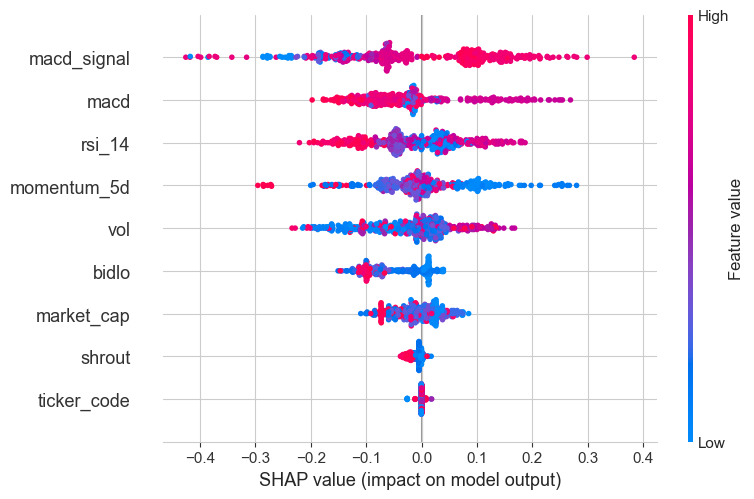

In [40]:
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[X_final.columns.tolist()]) 
shap.summary_plot(shap_values, X_test[X_final.columns.tolist()])# X_shap must be a DataFrame

In [43]:
df

NameError: name 'df_final' is not defined

In [48]:
selected_features =['rsi_14','macd_signal', 'macd']

In [254]:
df_recent[selected_features]

,permno,bidlo,vol,shrout,market_cap,momentum_5d,rsi_14,macd,macd_signal,ticker_code
0,19561,192.40,8624570.00,595983.00,116449.12,-0.03,49.83,6.69,1.88,0
1,66093,18.41,42149170.00,7127000.00,133559.98,-0.19,47.68,0.48,0.28,4
2,59408,33.21,35221501.00,8022432.00,268831.70,-0.25,49.14,1.40,0.87,1
3,70519,45.53,19563965.00,1936853.00,88669.13,-0.28,47.05,1.07,0.45,2
4,12369,33.40,11793319.00,1420697.00,48047.97,-0.45,47.80,1.29,1.03,3
...,...,...,...,...,...,...,...,...,...,...
2435,66093,22.44,25419992.00,7175289.00,162233.28,0.17,50.10,-0.20,-0.22,4
2436,70519,69.79,6664399.00,1891265.00,133126.14,0.45,54.00,0.64,-0.38,2
2437,19561,170.15,18082312.00,747576.00,131984.54,-0.01,48.61,1.24,-0.39,0
2438,59408,43.55,16109771.00,7672880.00,336916.16,0.16,53.31,1.13,0.36,1
